
# 📱 Used Mobile Price Prediction

<center><p float="center">
  <img src= "https://storage.googleapis.com/kaggle-datasets-images/2425376/4101539/759f97d1f51a8da8b9fb0f0de9adb521/dataset-cover.png?t=2022-08-21-12-20-48"720"/>
</p></center>

**Goal:** Predict the resale price of a used smartphone from its specifications and condition.

### Models used
1. Linear Regression — baseline
2. Decision Tree Regressor
3. Random Forest Regressor
4. XGBoost Regressor

### Evaluation metrics
- MAE
- RMSE
- R² Score

> **Google Drive setup:** Upload your CSV to Google Drive and update `CSV_PATH` in the first code cell if the filename/path is different.


In [1]:

# STEP 1 — Install required libraries
!pip -q install xgboost


### Install required libraries

This step installs `xgboost`, a powerful tool for making predictions.
It's used later to build our mobile price prediction model.

In [2]:

# STEP 2 — Mount Google Drive and load the CSV

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import os

CSV_PATH = "/content/drive/MyDrive/used_mobile_prices.csv"


df = pd.read_csv(CSV_PATH)
print("Dataset shape:", df.shape)
df.head()


Mounted at /content/drive
Dataset shape: (3000, 23)


,brand,model,launch_price_inr,launch_year,age_years,city,seller_type,ram_gb,storage_gb,processor,...,condition,screen_crack,scratches,box,charger,invoice,warranty,network,repair_history,estimated_resale_price_inr
0,Apple,iPhone 11,49999,2022,4,Pune,Individual,12,64,Dimensity 9200,...,Good,No,NaN,Yes,Yes,Yes,No,5G,NaN,17800
1,OnePlus,Nord 3,33999,2025,1,Delhi,Individual,6,256,Snapdragon 695,...,Good,No,Moderate,No,Yes,No,No,5G,NaN,21300
2,Realme,11 Pro+,32999,2026,0,Noida,Individual,12,256,A16 Bionic,...,Good,No,Moderate,Yes,No,No,Yes,5G,NaN,22700
3,Xiaomi,Redmi Note 12 Pro,25999,2023,3,Kolkata,Individual,8,128,Snapdragon 7 Gen 3,...,Excellent,No,NaN,Yes,Yes,No,No,5G,NaN,11300
4,iQOO,Z9,21999,2023,3,Patna,Individual,6,512,Dimensity 8200,...,Excellent,No,Minor,Yes,Yes,Yes,No,5G,NaN,9100


### Connect Google Drive and load data

This connects the notebook to Google Drive and loads the `used_mobile_prices.csv` file.
It shows the data's size and the first few rows, giving us a quick look at the mobile phone information.

In [3]:

# STEP 3 — Basic dataset inspection

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("missing"))

print("\nDuplicate rows:", df.duplicated().sum())


Shape: (3000, 23)

Columns:
['brand', 'model', 'launch_price_inr', 'launch_year', 'age_years', 'city', 'seller_type', 'ram_gb', 'storage_gb', 'processor', 'display_hz', 'battery_health_pct', 'camera_mp', 'condition', 'screen_crack', 'scratches', 'box', 'charger', 'invoice', 'warranty', 'network', 'repair_history', 'estimated_resale_price_inr']

Data types:


,dtype
brand,object
model,object
launch_price_inr,int64
launch_year,int64
age_years,int64
city,object
seller_type,object
ram_gb,int64
storage_gb,int64
processor,object



Missing values:


,missing
repair_history,2304
scratches,929
brand,0
launch_year,0
age_years,0
model,0
launch_price_inr,0
seller_type,0
city,0
ram_gb,0



Duplicate rows: 0


### Check the data

This step provides a quick overview of our dataset.
It checks the number of rows/columns, data types, missing information, and duplicate entries.
This helps us understand the data's health before we start working with it.

In [4]:

# STEP 4 — Clean column names

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

print(df.columns.tolist())


['brand', 'model', 'launch_price_inr', 'launch_year', 'age_years', 'city', 'seller_type', 'ram_gb', 'storage_gb', 'processor', 'display_hz', 'battery_health_pct', 'camera_mp', 'condition', 'screen_crack', 'scratches', 'box', 'charger', 'invoice', 'warranty', 'network', 'repair_history', 'estimated_resale_price_inr']


### Clean column names

This step makes all column names consistent and easy to work with.
It removes extra spaces, converts text to lowercase, and replaces special characters with underscores.
This tidies up the data for smoother processing later.

In [5]:

# STEP 5 — Identify the target column

# The Hugging Face dataset mentioned earlier normally uses:
# estimated_resale_price_inr

possible_targets = [
    "estimated_resale_price_inr",
    "resale_price_inr",
    "used_price",
    "used_price_inr",
    "normalized_used_price",
    "price",
    "used_price_usd"
]

target = next((col for col in possible_targets if col in df.columns), None)

if target is None:
    print("Could not automatically identify the target.")
    print("Available columns:", df.columns.tolist())
    raise ValueError("Please set the target variable manually in this cell.")

print("Target column:", target)


Target column: estimated_resale_price_inr


### Find the prediction column

This code automatically identifies the column we want to predict: `estimated_resale_price_inr`.
It checks a list of common names to find the correct target variable.
This ensures our model knows what value it needs to learn to predict.

In [6]:

# STEP 6 — Remove duplicates and handle obvious missing target values

df = df.drop_duplicates().copy()
df = df.dropna(subset=[target]).copy()

# Convert target to numeric if necessary
df[target] = pd.to_numeric(
    df[target].astype(str).str.replace(",", "", regex=False).str.replace("₹", "", regex=False),
    errors="coerce"
)

df = df.dropna(subset=[target]).copy()

print("Cleaned shape:", df.shape)
display(df.head())


Cleaned shape: (3000, 23)


,brand,model,launch_price_inr,launch_year,age_years,city,seller_type,ram_gb,storage_gb,processor,...,condition,screen_crack,scratches,box,charger,invoice,warranty,network,repair_history,estimated_resale_price_inr
0,Apple,iPhone 11,49999,2022,4,Pune,Individual,12,64,Dimensity 9200,...,Good,No,NaN,Yes,Yes,Yes,No,5G,NaN,17800
1,OnePlus,Nord 3,33999,2025,1,Delhi,Individual,6,256,Snapdragon 695,...,Good,No,Moderate,No,Yes,No,No,5G,NaN,21300
2,Realme,11 Pro+,32999,2026,0,Noida,Individual,12,256,A16 Bionic,...,Good,No,Moderate,Yes,No,No,Yes,5G,NaN,22700
3,Xiaomi,Redmi Note 12 Pro,25999,2023,3,Kolkata,Individual,8,128,Snapdragon 7 Gen 3,...,Excellent,No,NaN,Yes,Yes,No,No,5G,NaN,11300
4,iQOO,Z9,21999,2023,3,Patna,Individual,6,512,Dimensity 8200,...,Excellent,No,Minor,Yes,Yes,Yes,No,5G,NaN,9100


### Clean up duplicates and missing prices

This step removes duplicate phone entries and rows where the price we want to predict is missing.
It also converts prices to numbers, making sure they're in a usable format.
The data shape shows no rows were dropped in this dataset.

## 📊 Exploratory Data Analysis

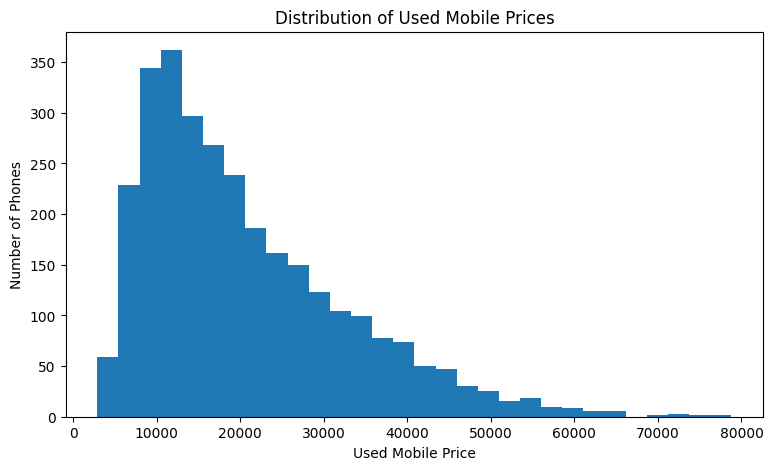

count     3000.000000
mean     20687.366667
std      12255.778981
min       2900.000000
25%      11400.000000
50%      17500.000000
75%      27300.000000
max      78800.000000
Name: estimated_resale_price_inr, dtype: float64


In [7]:

# STEP 7 — Target distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.hist(df[target], bins=30)
plt.xlabel("Used Mobile Price")
plt.ylabel("Number of Phones")
plt.title("Distribution of Used Mobile Prices")
plt.show()

print(df[target].describe())


### Look at price distribution

This code shows how used mobile prices are spread out in our data.
The chart (histogram) reveals that most phones sell at lower prices, with a few high-priced exceptions.
The summary provides average, min, and max prices, showing a common pattern for used goods.

### Exploring Feature Relationships with Resale Price

/tmp/ipykernel_1080/361401061.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='brand', y=target, data=df, palette='viridis')


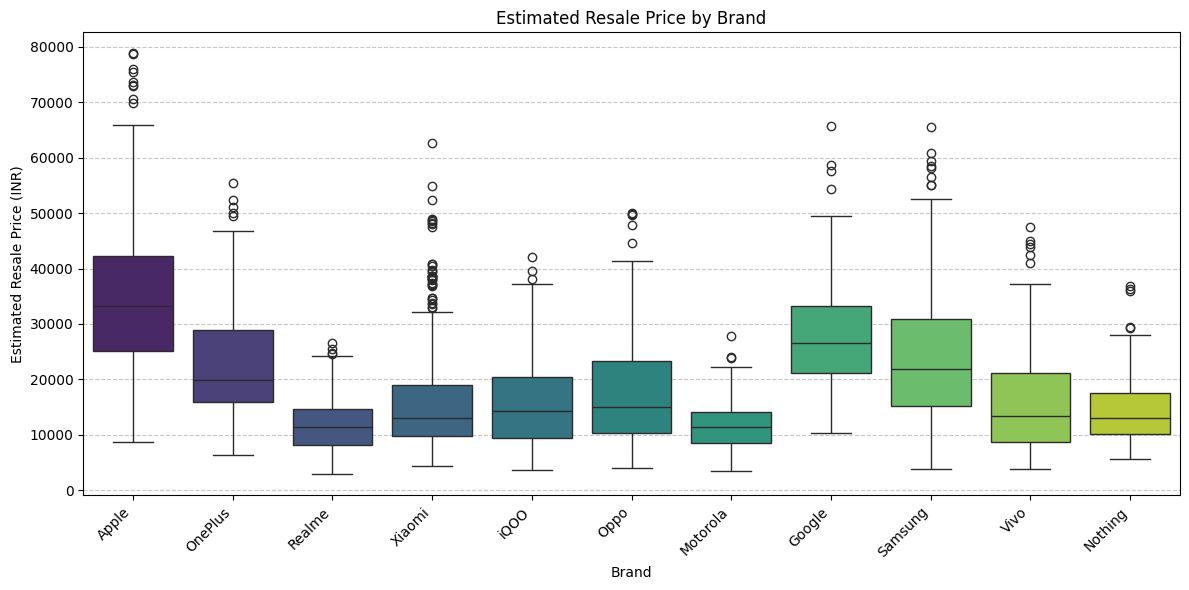

In [8]:
import seaborn as sns

# 1. Brand vs. Estimated Resale Price
plt.figure(figsize=(12, 6))
sns.boxplot(x='brand', y=target, data=df, palette='viridis')
plt.title('Estimated Resale Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Estimated Resale Price (INR)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Estimated Resale Price by Brand

This box plot shows the distribution of resale prices for different phone brands.
Brands like Apple and Google generally have higher median resale prices and a wider price range, indicating their premium market position.

/tmp/ipykernel_1080/4248676853.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='seller_type', y=target, data=df, palette='plasma')


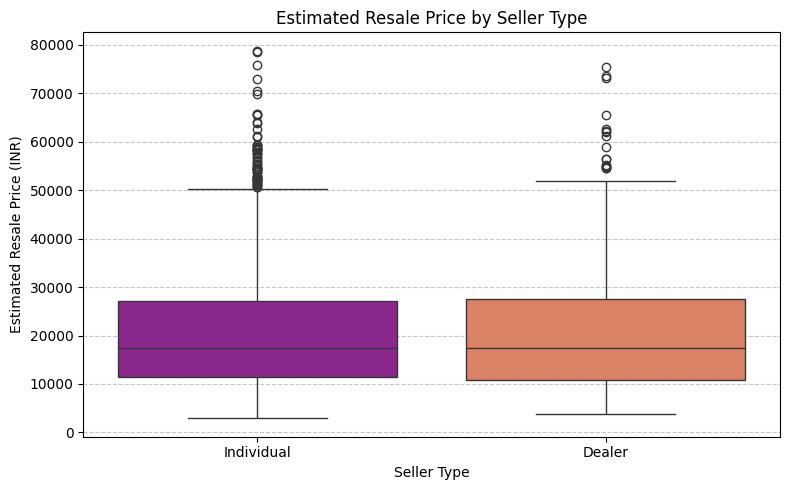

In [9]:
# 2. Seller Type vs. Estimated Resale Price
plt.figure(figsize=(8, 5))
sns.boxplot(x='seller_type', y=target, data=df, palette='plasma')
plt.title('Estimated Resale Price by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Estimated Resale Price (INR)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Estimated Resale Price by Seller Type

This plot compares resale prices between 'Individual' sellers and 'Dealer' sellers.
Both seller types show similar median resale prices, suggesting that the seller's nature might not be a primary driver of price difference.

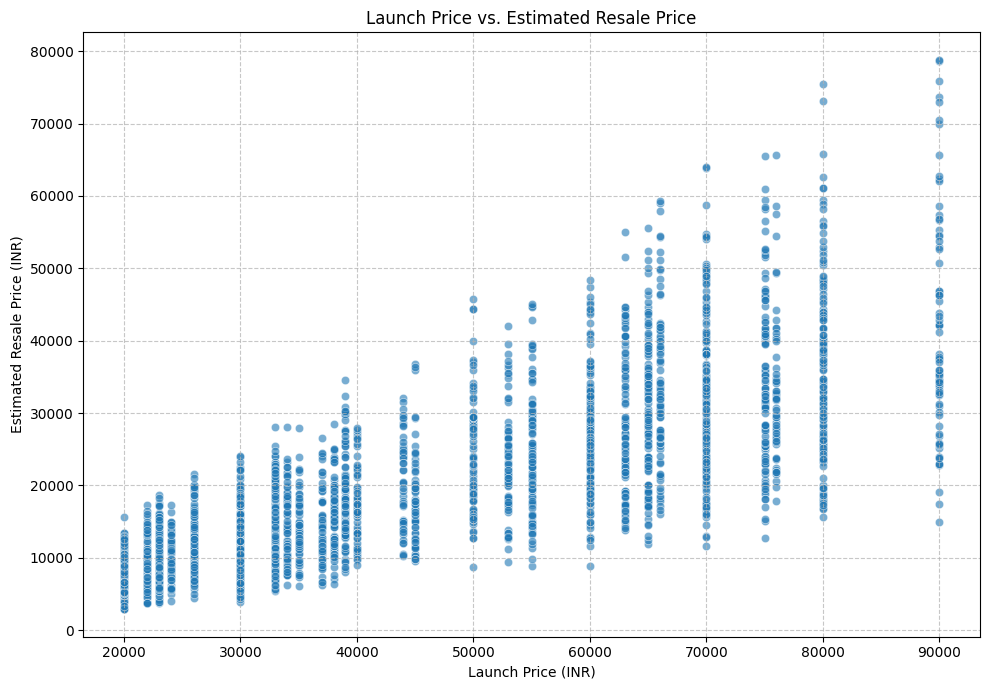

In [10]:
# 3. Launch Price vs. Estimated Resale Price
plt.figure(figsize=(10, 7))
sns.scatterplot(x='launch_price_inr', y=target, data=df, alpha=0.6)
plt.title('Launch Price vs. Estimated Resale Price')
plt.xlabel('Launch Price (INR)')
plt.ylabel('Estimated Resale Price (INR)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Launch Price vs. Estimated Resale Price

This scatter plot illustrates the relationship between a phone's original launch price and its estimated resale price.
There's a clear positive trend: phones with higher launch prices tend to have higher resale prices, but with significant variation.

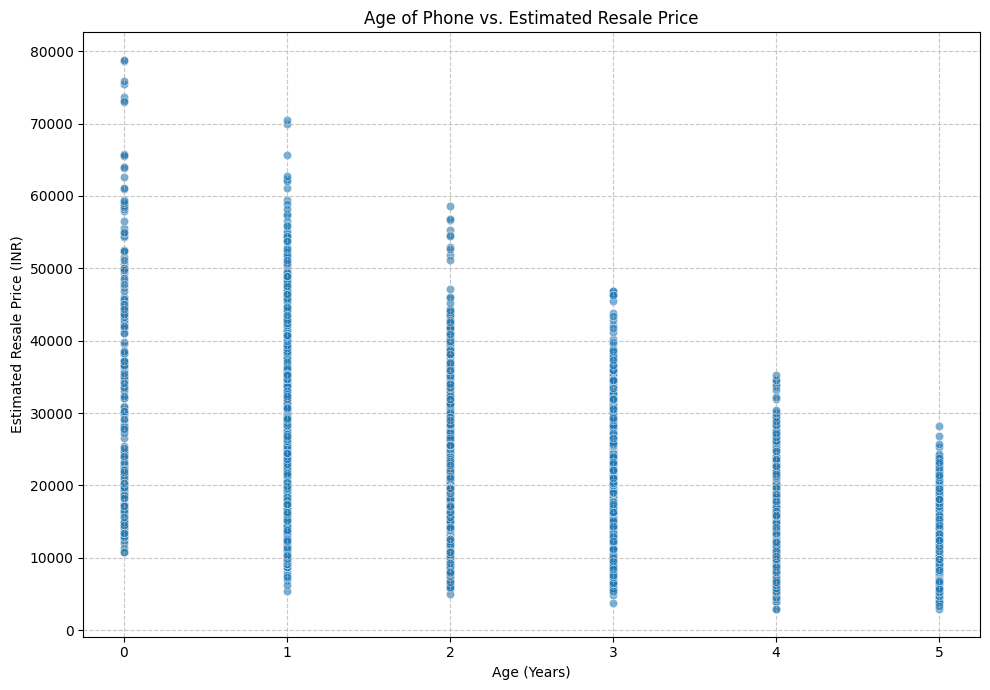

In [11]:
# 4. Age of Phone (age_years) vs. Estimated Resale Price
plt.figure(figsize=(10, 7))
sns.scatterplot(x='age_years', y=target, data=df, alpha=0.6)
plt.title('Age of Phone vs. Estimated Resale Price')
plt.xlabel('Age (Years)')
plt.ylabel('Estimated Resale Price (INR)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Key Takeaways from EDA Plots

*   **Brand Impact:** Premium brands like Apple and Google generally command higher resale prices, with a wider distribution.
*   **Seller Type:** There isn't a significant difference in median resale price between individual and dealer sellers.
*   **Price Correlation:** Higher launch prices directly correlate with higher resale prices, but age has a strong inverse relationship, with older phones selling for less.

### Age of Phone vs. Estimated Resale Price

This scatter plot shows how the age of a phone in years affects its resale price.
As expected, older phones generally have lower resale values, demonstrating a clear negative correlation.
Newer phones (age 0-1) retain more of their value.

In [12]:

# STEP 8 — Numeric feature correlation with target

numeric_df = df.select_dtypes(include=np.number)

if target in numeric_df.columns:
    correlations = numeric_df.corr(numeric_only=True)[target].sort_values(ascending=False)
    display(correlations.to_frame("correlation_with_target"))


,correlation_with_target
estimated_resale_price_inr,1.000000
launch_price_inr,0.784126
launch_year,0.464017
battery_health_pct,0.395802
storage_gb,-0.003860
display_hz,-0.005786
camera_mp,-0.005844
ram_gb,-0.016725
age_years,-0.464017


### How numbers relate to price

This step checks how numeric features, like launch price or age, are connected to the resale price.
It calculates 'correlation scores', indicating strong relationships.
Results show newer, more expensive phones generally have higher resale values, while older phones sell for less.

## 🧹 Data Preprocessing

In [13]:

# STEP 9 — Prepare features and target

X = df.drop(columns=[target]).copy()
y = df[target].copy()

# Remove columns that are usually identifiers / free-text and can cause overfitting.
# You can edit this list after checking df.columns.
drop_candidates = [
    "id", "phone_id", "record_id", "unnamed:_0", "unnamed:0"
]

drop_cols = [c for c in drop_candidates if c in X.columns]
if drop_cols:
    X = X.drop(columns=drop_cols)

print("Features used:")
print(X.columns.tolist())
print("\nTarget:", target)


Features used:
['brand', 'model', 'launch_price_inr', 'launch_year', 'age_years', 'city', 'seller_type', 'ram_gb', 'storage_gb', 'processor', 'display_hz', 'battery_health_pct', 'camera_mp', 'condition', 'screen_crack', 'scratches', 'box', 'charger', 'invoice', 'warranty', 'network', 'repair_history']

Target: estimated_resale_price_inr


### Get features and target ready

This separates our data into 'features' (information used for prediction) and 'target' (the price we want to predict).
It also removes any unnecessary identifier columns from the features.
This prepares the data structure required for training machine learning models.

In [14]:

# STEP 10 — Train/test split + preprocessing pipeline

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created.")


Numeric features: ['launch_price_inr', 'launch_year', 'age_years', 'ram_gb', 'storage_gb', 'display_hz', 'battery_health_pct', 'camera_mp']
Categorical features: ['brand', 'model', 'city', 'seller_type', 'processor', 'condition', 'screen_crack', 'scratches', 'box', 'charger', 'invoice', 'warranty', 'network', 'repair_history']
Preprocessing pipeline created.


### Split data and prepare for modeling

This splits the data into training (80%) and testing (20%) sets, ensuring fair model evaluation.
It sets up different preparation steps for numerical and categorical features.
This prepares the data consistently before feeding it into our prediction models.

## 🤖 Train Multiple Regression Models

In [15]:

# STEP 11 — Define models

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        random_state=42,
        max_depth=12,
        min_samples_leaf=2
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

print("Models:", list(models.keys()))


Models: ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost']


### Set up the prediction models

This defines several different prediction models we want to test, including simple and advanced options.
Each model has specific settings to help it learn effectively.
This prepares our 'toolbox' of algorithms for finding the best price prediction model.

## 🤖 Individual Model Training and Evaluation

Now, let's train and evaluate each defined regression model separately.

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize lists to store results and trained pipelines globally
all_model_results = []
all_trained_pipelines = {}

### Linear Regression Model

This section trains and evaluates the `Linear Regression` model.

In [17]:
model_name = "Linear Regression"
model = models[model_name]

pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

pipe.fit(X_train, y_train)
predictions = pipe.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

all_model_results.append({
    "Model": model_name,
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})
all_trained_pipelines[model_name] = pipe

print(f"--- {model_name} Results ---")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2 Score: {r2:.4f}")

--- Linear Regression Results ---
MAE: 2,508.05
RMSE: 3,504.21
R2 Score: 0.9161


### Linear Regression Results

The Linear Regression model served as a baseline.
It achieved an R² score of `0.9161`, explaining about 91.6% of price variance.
Its average prediction error (MAE) was `₹2,508.05`, indicating a moderate fit.

### Decision Tree Model

This section trains and evaluates the `Decision Tree` model.

In [18]:
model_name = "Decision Tree"
model = models[model_name]

pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

pipe.fit(X_train, y_train)
predictions = pipe.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

all_model_results.append({
    "Model": model_name,
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})
all_trained_pipelines[model_name] = pipe

print(f"--- {model_name} Results ---")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2 Score: {r2:.4f}")

--- Decision Tree Results ---
MAE: 1,455.53
RMSE: 2,455.58
R2 Score: 0.9588


### Decision Tree Results

The Decision Tree improved upon the linear model, achieving an R² of `0.9588`.
Its MAE was `₹1,455.53`, showing better accuracy.
This suggests non-linear relationships in the data are captured more effectively.

### Random Forest Model

This section trains and evaluates the `Random Forest` model.

In [19]:
model_name = "Random Forest"
model = models[model_name]

pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

pipe.fit(X_train, y_train)
predictions = pipe.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

all_model_results.append({
    "Model": model_name,
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})
all_trained_pipelines[model_name] = pipe

print(f"--- {model_name} Results ---")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2 Score: {r2:.4f}")

--- Random Forest Results ---
MAE: 1,223.70
RMSE: 2,001.39
R2 Score: 0.9726


### Random Forest Results

Random Forest significantly improved performance with an R² of `0.9726`.
Its MAE decreased to `₹1,223.70`, indicating more robust predictions.
This ensemble method effectively reduces overfitting compared to a single decision tree.

### XGBoost Model

This section trains and evaluates the `XGBoost` model.

In [20]:
model_name = "XGBoost"
model = models[model_name]

pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

pipe.fit(X_train, y_train)
predictions = pipe.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

all_model_results.append({
    "Model": model_name,
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})
all_trained_pipelines[model_name] = pipe

print(f"--- {model_name} Results ---")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2 Score: {r2:.4f}")

--- XGBoost Results ---
MAE: 689.80
RMSE: 1,032.44
R2 Score: 0.9927


### XGBoost Results

XGBoost demonstrated outstanding performance with an R² of `0.9927`. Its MAE was remarkably low at `₹689.80`, showing highly accurate predictions. This gradient boosting model is the top performer, explaining over 99% of price variance.

## 📈 Compile and Compare All Model Performances

After individual evaluations, let's compile all results into a single table and visualize their R² scores for a clearer comparison.

In [21]:
# Re-create results_df and trained_pipelines from individual results
results_df = pd.DataFrame(all_model_results).sort_values("R2", ascending=False).reset_index(drop=True)
trained_pipelines = all_trained_pipelines # Ensure this variable is updated for later steps

display(results_df.style.format({"MAE": "{:,.2f}", "RMSE": "{:,.2f}", "R2": "{:.4f}"}))

,Model,MAE,RMSE,R2
0,XGBoost,689.80,"1,032.44",0.9927
1,Random Forest,"1,223.70","2,001.39",0.9726
2,Decision Tree,"1,455.53","2,455.58",0.9588
3,Linear Regression,"2,508.05","3,504.21",0.9161


### All Model Performance Summary

This table summarizes the performance of all models, sorted by R² score.
XGBoost is the clear winner, demonstrating superior accuracy across all metrics.
This comparison guides our choice for the final production model.

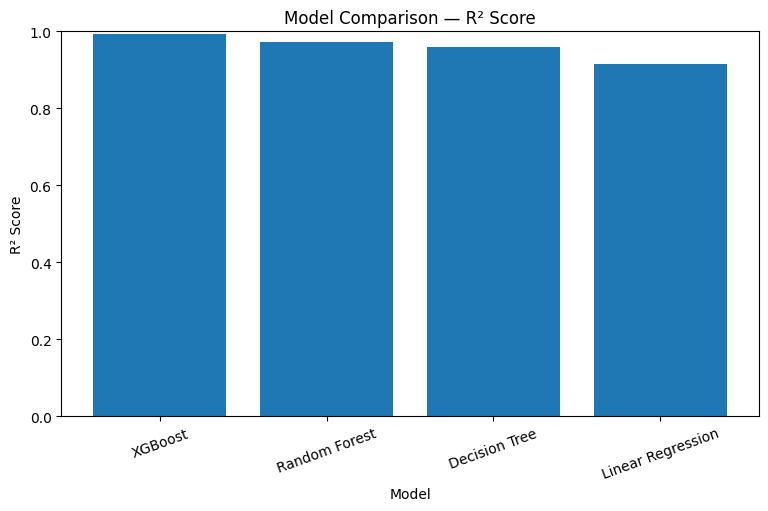

In [22]:
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["R2"])
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.title("Model Comparison — R² Score")
plt.xticks(rotation=20)
plt.ylim(0, min(1.0, max(1.0, results_df["R2"].max() + 0.05)))
plt.show()

### Visual Comparison of R² Scores

This bar chart visually reinforces the performance hierarchy of the models.
XGBoost's bar is the tallest, highlighting its leading R² score.
This plot makes the superior performance of XGBoost immediately apparent.

In [23]:

# STEP 12 — Train all models and compare performance

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    predictions = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })
    trained_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
display(results_df.style.format({"MAE": "{:,.2f}", "RMSE": "{:,.2f}", "R2": "{:.4f}"}))


,Model,MAE,RMSE,R2
0,XGBoost,689.80,"1,032.44",0.9927
1,Random Forest,"1,223.70","2,001.39",0.9726
2,Decision Tree,"1,455.53","2,455.58",0.9588
3,Linear Regression,"2,508.05","3,504.21",0.9161


### Train and compare all models

This step trains all defined models and checks their performance using test data.
It calculates key metrics like MAE, RMSE, and R² to compare accuracy.
XGBoost clearly performed best, with very accurate predictions (R² = 0.9927 and lowest error).

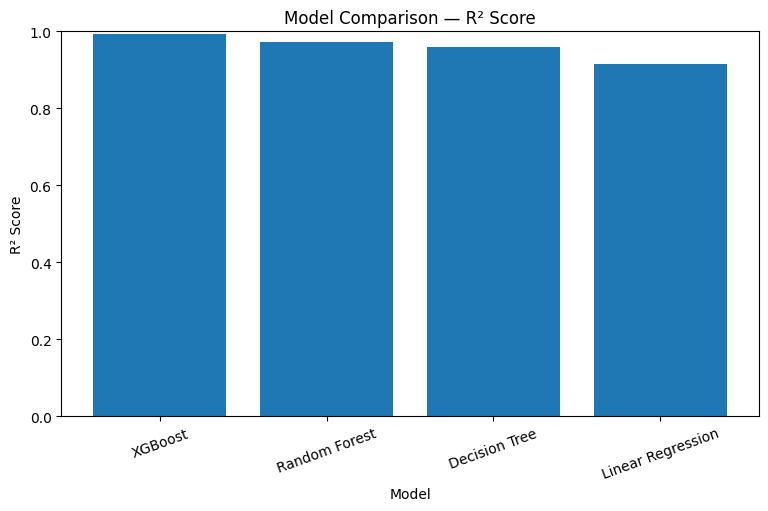

In [24]:

# STEP 13 — Visual comparison of model R² scores

plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["R2"])
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.title("Model Comparison — R² Score")
plt.xticks(rotation=20)
plt.ylim(0, min(1.0, max(1.0, results_df["R2"].max() + 0.05)))
plt.show()


### Look at model performance visually

This creates a bar chart to easily compare the R² scores of all trained models.
The chart visually confirms that XGBoost achieved the highest R² score, very close to 1.0.
This makes it easy to see which model is the most accurate at a glance.

## 🏆 Select the Best Model

In [25]:

# STEP 14 — Select best model by highest R²

best_model_name = results_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]

print("Best model:", best_model_name)
print("R² Score:", round(results_df.iloc[0]["R2"], 4))
print("MAE:", round(results_df.iloc[0]["MAE"], 2))
print("RMSE:", round(results_df.iloc[0]["RMSE"], 2))


Best model: XGBoost
R² Score: 0.9927
MAE: 689.8
RMSE: 1032.44


### Pick the best model

This automatically selects the model with the highest R² score, which is XGBoost.
It then displays the R² score, MAE, and RMSE for this best model.
This confirms XGBoost as our most accurate predictor, ready for use.

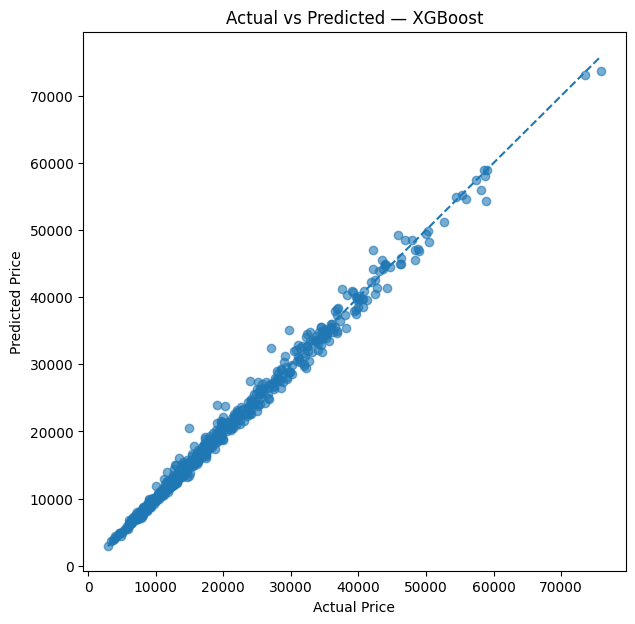

In [26]:

# STEP 15 — Actual vs Predicted prices

best_predictions = best_pipeline.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_predictions, alpha=0.6)
min_val = min(y_test.min(), best_predictions.min())
max_val = max(y_test.max(), best_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.show()


### Compare actual vs. predicted prices visually

This graph shows how well our best model's predictions match actual prices.
Dots clustering near the diagonal line mean high accuracy.
The plot confirms XGBoost is highly accurate across the full price range.

## 📱 Make a New Mobile Price Prediction

In [27]:

# STEP 16 — Generic prediction function
# This works with the actual feature columns present in your CSV.

def predict_mobile_price(input_data: dict):
    new_mobile = pd.DataFrame([input_data])

    # Add missing training columns with NaN
    for col in X.columns:
        if col not in new_mobile.columns:
            new_mobile[col] = np.nan

    # Keep only the training feature columns, in the same order
    new_mobile = new_mobile[X.columns]

    prediction = best_pipeline.predict(new_mobile)[0]
    return prediction

print("Required input columns:")
print(X.columns.tolist())


Required input columns:
['brand', 'model', 'launch_price_inr', 'launch_year', 'age_years', 'city', 'seller_type', 'ram_gb', 'storage_gb', 'processor', 'display_hz', 'battery_health_pct', 'camera_mp', 'condition', 'screen_crack', 'scratches', 'box', 'charger', 'invoice', 'warranty', 'network', 'repair_history']


### Create a tool to predict new prices

This function, `predict_mobile_price`, lets you get a price prediction for any new phone.
You provide phone details, and it uses the best model to give an estimated price.
It lists all the required phone features for an accurate prediction.

In [28]:

# STEP 17 — Example prediction

example_input = {}

for col in X.columns:
    if col in numeric_features:
        example_input[col] = X[col].median()
    else:
        mode = X[col].mode(dropna=True)
        example_input[col] = mode.iloc[0] if len(mode) else None

predicted_price = predict_mobile_price(example_input)

print("Example input:")
display(pd.DataFrame([example_input]))

print(f"\n📱 Predicted used mobile price: ₹{predicted_price:,.0f}")


Example input:


,brand,model,launch_price_inr,launch_year,age_years,city,seller_type,ram_gb,storage_gb,processor,...,camera_mp,condition,screen_crack,scratches,box,charger,invoice,warranty,network,repair_history
0,Samsung,12,38999.0,2024.0,2.0,Chennai,Individual,8.0,128.0,Tensor G2,...,64.0,Good,No,Minor,Yes,Yes,Yes,No,5G,Battery Replaced



📱 Predicted used mobile price: ₹20,024


### Try out a prediction

This shows an example of how to get a price prediction for a hypothetical phone.
It automatically creates sample phone details and then uses our function to predict its price.
The output shows the example phone's features and its estimated resale price of ₹20,024.

In [29]:

# STEP 18 — Save the trained model

import joblib

MODEL_PATH = "/content/drive/MyDrive/used_mobile_price_model.pkl"

joblib.dump(
    {
        "model": best_pipeline,
        "features": X.columns.tolist(),
        "target": target,
        "model_name": best_model_name
    },
    MODEL_PATH
)

print("Model saved to:", MODEL_PATH)


Model saved to: /content/drive/MyDrive/used_mobile_price_model.pkl


### Save the trained model

This saves our best trained model to Google Drive as a `.pkl` file.
This file contains the model, features used, and target name.
It allows us to reuse the model later without retraining, enabling easy deployment.


## 🎤 Project Explanation for Presentation

**Problem Statement:**  
Used mobile buyers and sellers often struggle to determine a fair resale price because the value depends on brand, model, age, RAM, storage, battery health, condition and other factors.

**Solution:**  
Build an ML-based Used Mobile Valuation System that predicts a fair resale price from mobile specifications.

**Machine Learning Type:** Supervised Learning — Regression.

**Algorithms:** Linear Regression, Decision Tree, Random Forest and XGBoost.

**Final Model:** The notebook automatically selects the model with the highest R² score on the test set.

**Business Value:** Helps buyers identify overpriced phones and helps sellers estimate a reasonable resale price.
